<a href="https://colab.research.google.com/github/dibyadarshandash8934-dev/ml-research/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. LOAD AND EXPLORE DATASET
Shape: (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
0              5.100             3.500              1.400             0.200  setosa
1              4.900             3.000              1.400             0.200  setosa
2              4.700             3.200              1.300             0.200  setosa
3              4.600             3.100              1.500             0.200  setosa
4              5.000             3.600              1.400             0.200  setosa


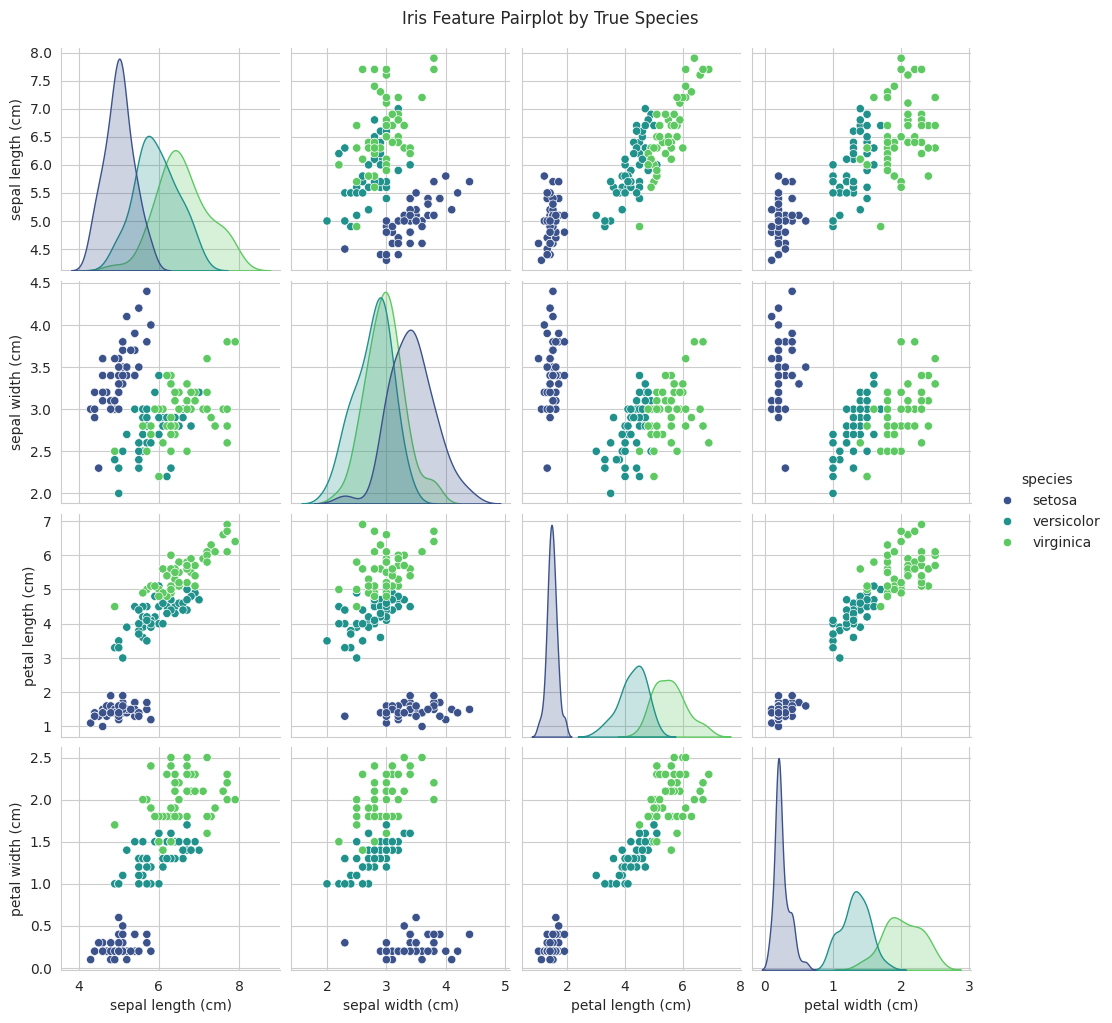


2. PREPROCESSING
Variance explained by 2 PCs: 95.81%


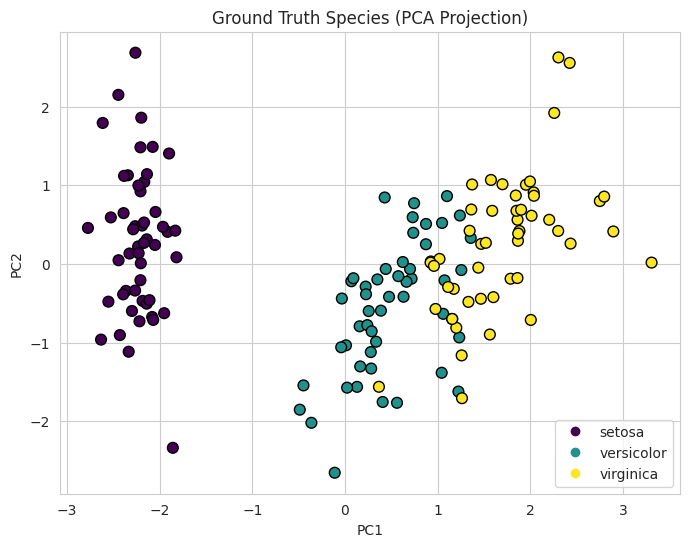


3. EVALUATION HELPERS

4. K-MEANS
K-Means                   clusters=3  noise=0  silhouette=0.460  ARI=0.620  NMI=0.659


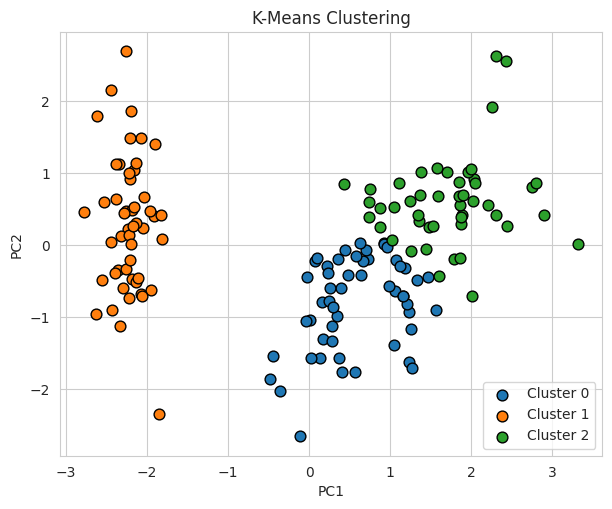


5. AGGLOMERATIVE HIERARCHICAL CLUSTERING


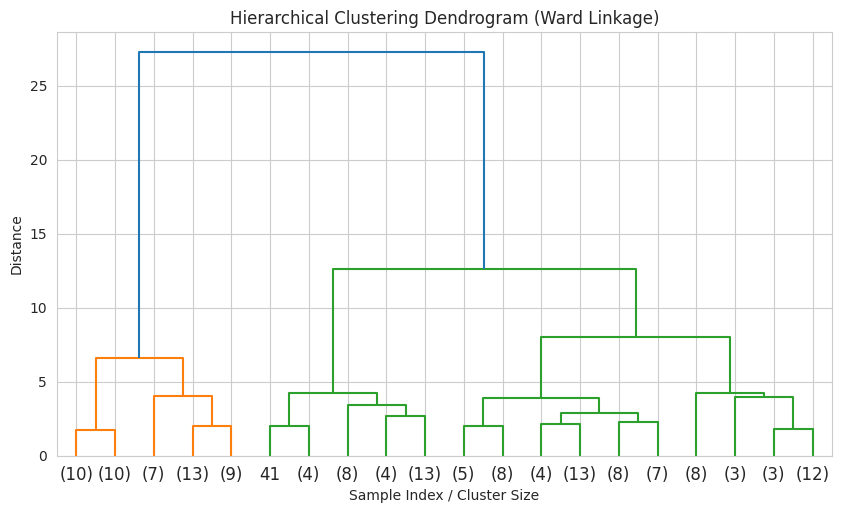

Hierarchical (Ward)       clusters=3  noise=0  silhouette=0.447  ARI=0.615  NMI=0.675


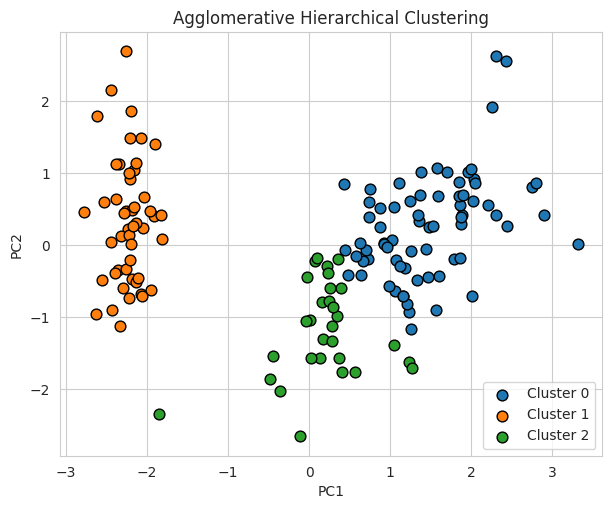


6. DBSCAN
DBSCAN                    clusters=2  noise=4  silhouette=0.598  ARI=0.552  NMI=0.690


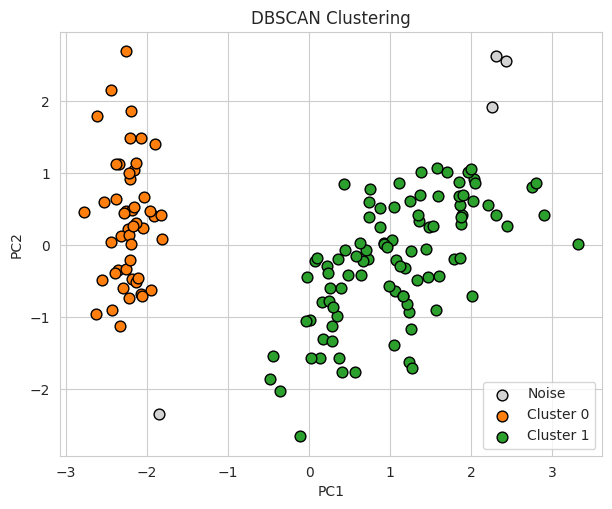


7. GAUSSIAN MIXTURE MODEL
Gaussian Mixture Model    clusters=3  noise=0  silhouette=0.475  ARI=0.516  NMI=0.657


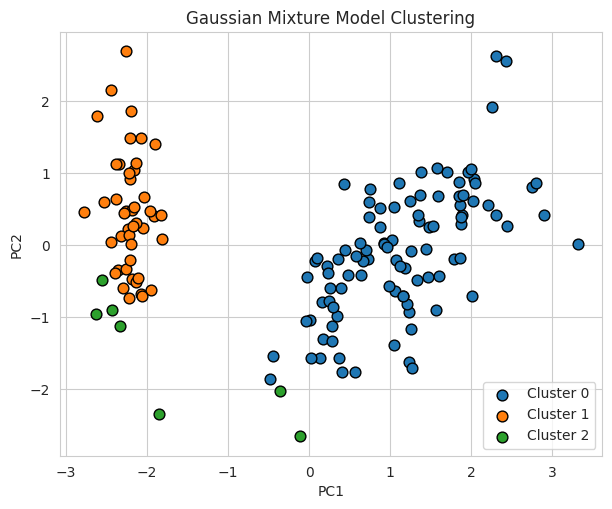


8. SPECTRAL CLUSTERING
Spectral Clustering       clusters=3  noise=0  silhouette=0.459  ARI=0.646  NMI=0.684


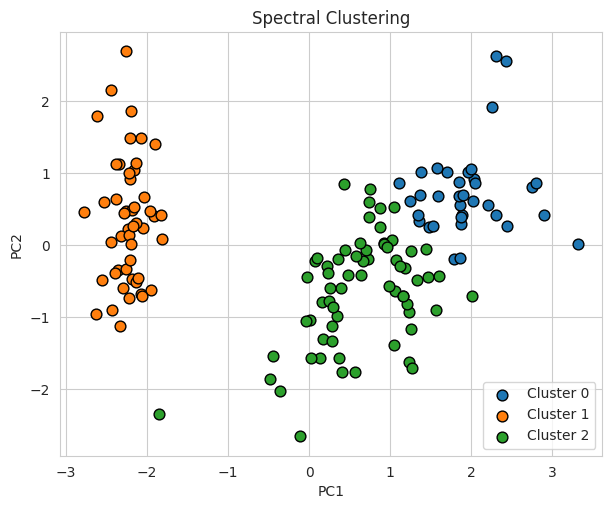


9. MEAN SHIFT
Mean Shift                clusters=4  noise=0  silhouette=0.358  ARI=0.536  NMI=0.660


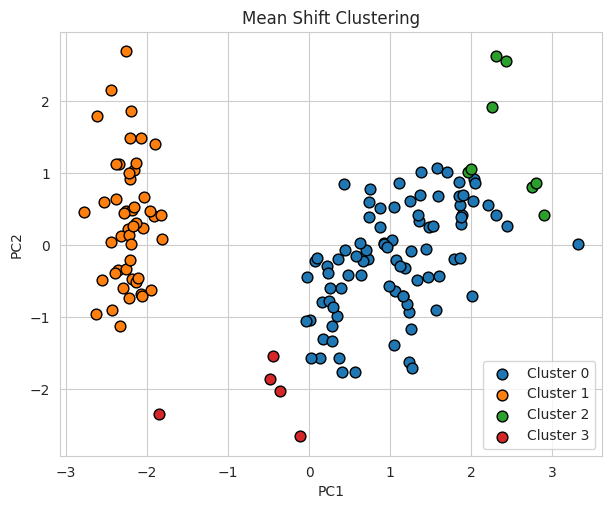


10. OPTICS
OPTICS                    clusters=5  noise=91  silhouette=0.503  ARI=0.099  NMI=0.370


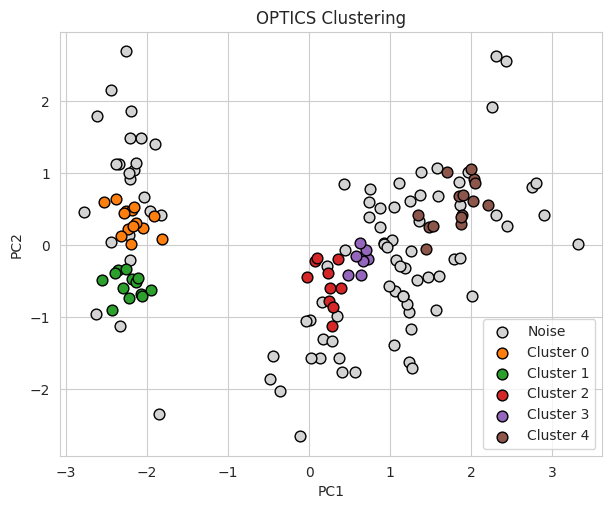


11. BIRCH
BIRCH                     clusters=3  noise=0  silhouette=0.454  ARI=0.661  NMI=0.733


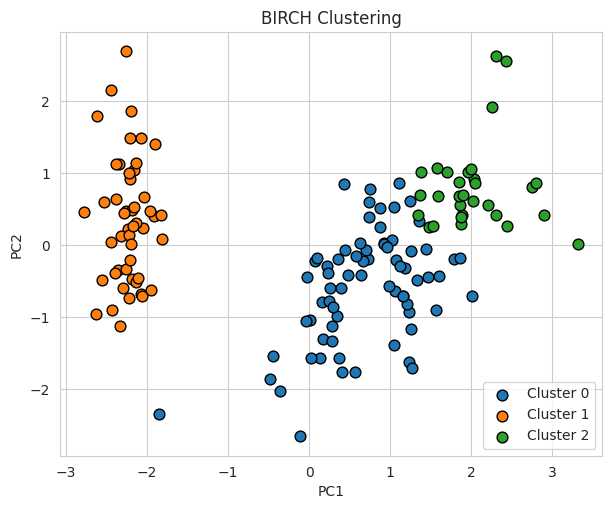


12. COMPARISON SUMMARY
                Method  Clusters Found  Noise Points  Silhouette  Davies-Bouldin  Calinski-Harabasz   ARI   NMI
                DBSCAN               2             4       0.598           0.569            277.651 0.552 0.690
                OPTICS               5            91       0.503           0.735            321.127 0.099 0.370
Gaussian Mixture Model               3             0       0.475           0.887            141.231 0.516 0.657
               K-Means               3             0       0.460           0.834            241.904 0.620 0.659
   Spectral Clustering               3             0       0.459           0.822            229.680 0.646 0.684
                 BIRCH               3             0       0.454           0.822            219.819 0.661 0.733
   Hierarchical (Ward)               3             0       0.447           0.803            222.719 0.615 0.675
            Mean Shift               4             0       0.358           0.776

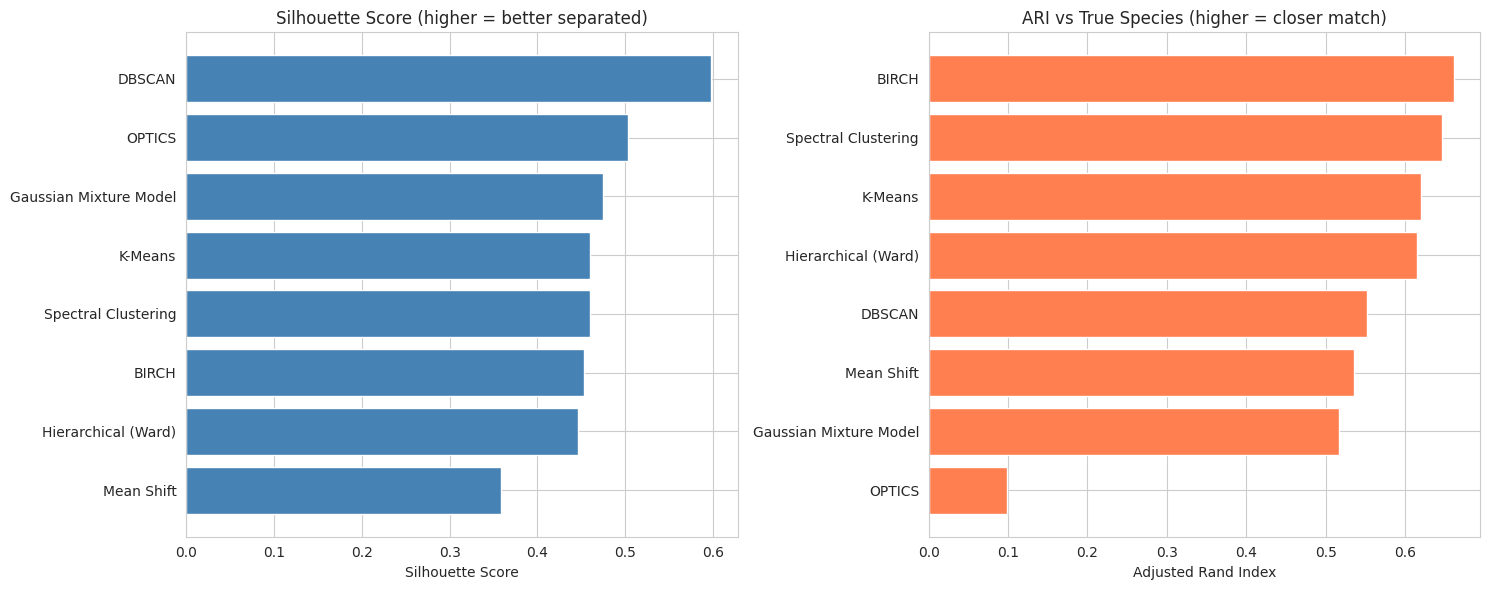

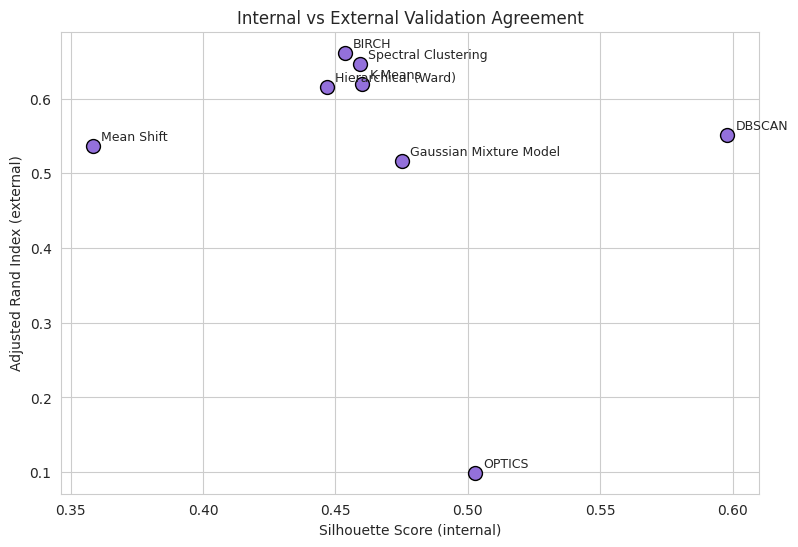


13. BEST PERFORMERS
Best by Silhouette (internal): DBSCAN
Best by ARI (closest to true species): BIRCH


In [2]:
# ============================================================
# Clustering Techniques Comparison on the Iris Dataset
# Compares 8 algorithms using internal + external validation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering,
    MeanShift, OPTICS, Birch, estimate_bandwidth
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
np.random.seed(42)

# Full-precision, non-truncated table display
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


def section(title):
    """Print a banner so script output is easy to scan when run top to bottom."""
    print('\n' + '=' * 65)
    print(title.upper())
    print('=' * 65)


# ------------------------------------------------------------
# 1. Load and explore the dataset
# ------------------------------------------------------------
section('1. Load and Explore Dataset')

iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y_true, target_names)

print(f"Shape: {df.shape}")
print(df.head())

sns.pairplot(df, hue='species', diag_kind='kde', palette='viridis')
plt.suptitle('Iris Feature Pairplot by True Species', y=1.02)
plt.show()

# ------------------------------------------------------------
# 2. Preprocessing: standardize features, project to 2D for plots only
# ------------------------------------------------------------
section('2. Preprocessing')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)                     # all clustering runs on this scaled 4D data

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)                    # PCA is ONLY for 2D visualization below
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=60, edgecolor='k')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Ground Truth Species (PCA Projection)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
plt.show()

# ------------------------------------------------------------
# 3. Evaluation helpers
# ------------------------------------------------------------
section('3. Evaluation Helpers')

results = []


def evaluate(name, labels, X_data=X_scaled):
    """
    Score one clustering result and store/print a summary row.
    Internal metrics (no true labels needed): Silhouette, Davies-Bouldin, Calinski-Harabasz.
    External metrics (compared against true species, for benchmarking only): ARI, NMI.
    """
    mask = labels != -1                                 # drop DBSCAN/OPTICS noise (-1) from internal metrics
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0

    if n_clusters > 1 and mask.sum() > 1:
        sil = silhouette_score(X_data[mask], labels[mask])
        db = davies_bouldin_score(X_data[mask], labels[mask])
        ch = calinski_harabasz_score(X_data[mask], labels[mask])
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    n_noise = int((labels == -1).sum())

    results.append({
        'Method': name, 'Clusters Found': n_clusters, 'Noise Points': n_noise,
        'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch,
        'ARI': ari, 'NMI': nmi
    })

    print(f"{name:<25} clusters={n_clusters}  noise={n_noise}  "
          f"silhouette={sil:.3f}  ARI={ari:.3f}  NMI={nmi:.3f}")


def plot_clusters(name, labels):
    """Scatter the PCA projection, colored by predicted cluster (gray = noise point)."""
    plt.figure(figsize=(7, 5.5))
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for i, lab in enumerate(unique_labels):
        mask = labels == lab
        color = 'lightgray' if lab == -1 else palette[i]
        marker_label = 'Noise' if lab == -1 else f'Cluster {lab}'
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=60, color=color, edgecolor='k', label=marker_label)
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(name)
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# 4. K-Means — centroid-based, assumes roughly spherical clusters
# ------------------------------------------------------------
section('4. K-Means')

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
evaluate('K-Means', labels_kmeans)
plot_clusters('K-Means Clustering', labels_kmeans)

# ------------------------------------------------------------
# 5. Agglomerative Hierarchical Clustering (Ward linkage)
# ------------------------------------------------------------
section('5. Agglomerative Hierarchical Clustering')

linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5.5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index / Cluster Size'); plt.ylabel('Distance')
plt.show()

agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agglo = agglo.fit_predict(X_scaled)
evaluate('Hierarchical (Ward)', labels_agglo)
plot_clusters('Agglomerative Hierarchical Clustering', labels_agglo)

# ------------------------------------------------------------
# 6. DBSCAN — density-based, flags noise, no k needed
# ------------------------------------------------------------
section('6. DBSCAN')

dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
evaluate('DBSCAN', labels_dbscan)
plot_clusters('DBSCAN Clustering', labels_dbscan)

# ------------------------------------------------------------
# 7. Gaussian Mixture Model — probabilistic, elliptical clusters
# ------------------------------------------------------------
section('7. Gaussian Mixture Model')

gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
evaluate('Gaussian Mixture Model', labels_gmm)
plot_clusters('Gaussian Mixture Model Clustering', labels_gmm)

# ------------------------------------------------------------
# 8. Spectral Clustering — graph-based, handles non-convex shapes
# ------------------------------------------------------------
section('8. Spectral Clustering')

spectral = SpectralClustering(n_clusters=3, random_state=42, affinity='nearest_neighbors', n_neighbors=10)
labels_spectral = spectral.fit_predict(X_scaled)
evaluate('Spectral Clustering', labels_spectral)
plot_clusters('Spectral Clustering', labels_spectral)

# ------------------------------------------------------------
# 9. Mean Shift — mode-seeking, cluster count found automatically
# ------------------------------------------------------------
section('9. Mean Shift')

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, random_state=42)
mean_shift = MeanShift(bandwidth=bandwidth)
labels_meanshift = mean_shift.fit_predict(X_scaled)
evaluate('Mean Shift', labels_meanshift)
plot_clusters('Mean Shift Clustering', labels_meanshift)

# ------------------------------------------------------------
# 10. OPTICS — like DBSCAN but handles varying cluster density
# ------------------------------------------------------------
section('10. OPTICS')

optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
labels_optics = optics.fit_predict(X_scaled)
evaluate('OPTICS', labels_optics)
plot_clusters('OPTICS Clustering', labels_optics)

# ------------------------------------------------------------
# 11. BIRCH — tree-based summarization, scales to large datasets
# ------------------------------------------------------------
section('11. BIRCH')

birch = Birch(n_clusters=3)
labels_birch = birch.fit_predict(X_scaled)
evaluate('BIRCH', labels_birch)
plot_clusters('BIRCH Clustering', labels_birch)

# ------------------------------------------------------------
# 12. Comparison summary across all 8 methods
# ------------------------------------------------------------
section('12. Comparison Summary')

results_df = pd.DataFrame(results).sort_values('Silhouette', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sil_sorted = results_df.sort_values('Silhouette', ascending=True)
axes[0].barh(sil_sorted['Method'], sil_sorted['Silhouette'], color='steelblue')
axes[0].set_xlabel('Silhouette Score')
axes[0].set_title('Silhouette Score (higher = better separated)')

ari_sorted = results_df.sort_values('ARI', ascending=True)
axes[1].barh(ari_sorted['Method'], ari_sorted['ARI'], color='coral')
axes[1].set_xlabel('Adjusted Rand Index')
axes[1].set_title('ARI vs True Species (higher = closer match)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(results_df['Silhouette'], results_df['ARI'], s=100, color='mediumpurple', edgecolor='k')
for _, row in results_df.iterrows():
    plt.annotate(row['Method'], (row['Silhouette'], row['ARI']), textcoords='offset points', xytext=(6, 4), fontsize=9)
plt.xlabel('Silhouette Score (internal)')
plt.ylabel('Adjusted Rand Index (external)')
plt.title('Internal vs External Validation Agreement')
plt.show()

# ------------------------------------------------------------
# 13. Final takeaway
# ------------------------------------------------------------
section('13. Best Performers')
print("Best by Silhouette (internal):", results_df.iloc[0]['Method'])
print("Best by ARI (closest to true species):", results_df.sort_values('ARI', ascending=False).iloc[0]['Method'])